In [1]:
import sys
from pathlib import Path

import os

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

# Now append the src directory to the path
import sys
sys.path.append(str(Path('src').resolve()))

import numpy as np
import pandas as pd
# Now import the necessary modules
from config import Config
import argparse
import logging
from pathlib import Path
from config import Config, setup_logging
from model import get_models
from data_loader import (
    StockDataset,
    download_stock_data,
    get_sp500_tickers,
    prepare_data,
    create_dataloader
)
from trainer import GANTrainer
from evaluation import (
    generate_synthetic_data,
    evaluate_quality,
    plot_results,
    plot_training_history,
    analyze_distributions
)
# Initialize configuration and check the data directory
config = Config()
print(f"Data directory: {config.DATA_DIR}")

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Fetch S&P 500 tickers and download stock data
tickers = get_sp500_tickers(config)
stock_data = download_stock_data(tickers, config)
# stock_data

INFO:data_loader:Loaded data for 495 stocks


Data directory: data
data/stock_data.pkl


In [2]:
logger = setup_logging(config)

logger.info(f'Using device: {config.DEVICE}')
logger.info(f'Number of GPUs: {config.NUM_GPUS}')
logger.info(f'Batch size: {config.BATCH_SIZE}')
# logger.info(f'Learning rate: {config.BASE_LR}')


2024-11-01 00:20:05,066 - INFO - Using device: cpu
INFO:GAN_Training:Using device: cpu
2024-11-01 00:20:05,068 - INFO - Number of GPUs: 0
INFO:GAN_Training:Number of GPUs: 0
2024-11-01 00:20:05,069 - INFO - Batch size: 16
INFO:GAN_Training:Batch size: 16


In [3]:
def robust_normalize(data: np.ndarray) -> np.ndarray:
    """
    Normalize the input data using the median and IQR method.

    Args:
        data (np.ndarray): The data to normalize, expected to be 2D.

    Returns:
        np.ndarray: Normalized data.
    """
    median = np.nanmedian(data, axis=0)  # Ignore NaNs
    q75, q25 = np.nanpercentile(data, [75, 25], axis=0)
    iqr = q75 - q25
    normalized_data = (data - median) / (iqr + 1e-8)  # Avoid division by zero
    return normalized_data

In [4]:
# num_stocks = 2
# rows_per_stock = 100

# np.random.seed(31)

# # Select stocks if num_stocks is specified
# if num_stocks is not None:
#     selected_stocks = np.random.choice(list(stock_data.keys()), num_stocks, replace=False)
# else:
#     selected_stocks = list(stock_data.keys())
# print("Selected stocks:", selected_stocks)

# # Create a mapping of stock names to unique IDs
# stock_to_id = {stock: idx for idx, stock in enumerate(selected_stocks)}
# print('stock_to_id:', stock_to_id)

# # Get the full date range from the stock data
# min_date = min(df.index.min() for df in stock_data.values())
# max_date = max(df.index.max() for df in stock_data.values())
# all_dates = pd.date_range(start=min_date, end=max_date, freq='B')

# # Initialize dictionaries
# real_data_dict = {}
# aligned_data_dict = {}
# mask_dict = {}
# normalization_params = {}

# for stock in selected_stocks:
#     # Align stock data with the full date range
#     df = stock_data[stock]
#     df_aligned = df.reindex(all_dates)
#     mask = df_aligned.notna().astype(int)
    
#     real_data_dict[stock] = df_aligned.iloc[:rows_per_stock]
#     print('df_aligned')
#     display(df_aligned)
    
#     # Normalize data
#     normalized_data = robust_normalize(df_aligned.values)
#     normalized_df = pd.DataFrame(normalized_data, index=all_dates, columns=df.columns)
#     print('normalized_df')
#     display(normalized_df)
#     normalized_df[mask == 0] = np.nan  # Keep NaNs where the original data is missing

#     # Now, select only the specified number of non-NaN rows
#     non_nan_rows = normalized_df.dropna().iloc[:rows_per_stock]

#     # Store only the selected rows in the final dictionaries
#     aligned_data_dict[stock] = non_nan_rows
#     mask_dict[stock] = mask.loc[non_nan_rows.index]
#     normalization_params[stock] = (
#         np.nanmedian(df_aligned.values, axis=0),
#         np.nanpercentile(df_aligned.values, 75, axis=0) - np.nanpercentile(df_aligned.values, 25, axis=0)
#     )

# # aligned_data_dict


In [5]:
# num_stocks = len(stock_to_id)  # Set number of stocks dynamically
# logger.info(f'Number of unique stocks (NUM_STOCKS): {num_stocks}')

In [6]:
# data = []
# masks = []
# stock_ids = []

# for stock, stock_id in stock_to_id.items():
#     stock_data = aligned_data_dict[stock].to_numpy().astype(np.float32)
#     stock_mask = mask_dict[stock].to_numpy().astype(np.float32)

#     valid_data = stock_data[~np.isnan(stock_data).any(axis=1)]
#     valid_masks = stock_mask[~np.isnan(stock_mask).any(axis=1)]

#     data.append(valid_data)
#     masks.append(valid_masks)
#     stock_ids.extend([stock_id] * len(valid_data))

# # stock_data

In [7]:
# data[0].shape

In [8]:
# len(data)

In [9]:
# # dataloader = create_dataloader(config, aligned_data_dict, mask_dict, stock_to_id)
# # dataloader

# config = Config()

# # Prepare your stock data
# aligned_data_dict, mask_dict, norm_params, stock_to_id = prepare_data(
#     stock_data, 
#     num_stocks=2,  # Your number of stocks
#     rows_per_stock=100  # Your rows per stock
# )

# # Create dataloader
# dataloader = create_dataloader(
#     config,
#     aligned_data_dict,
#     mask_dict,
#     stock_to_id
# )

In [10]:
# # Initialize models
# generator, discriminator = get_models(config)

# # GAN Training
# trainer = GANTrainer(config, generator, discriminator, dataloader)

# main.py

import torch
import torch.optim as optim
from config import Config
from model import TransformerGenerator, Discriminator, init_weights  # Import model classes directly
from data_loader import create_dataloader  # Import dataloader function
from trainer import GANTrainer  # Import the training class

num_stocks=2
rows_per_stock=100

config = Config()
print("Configuration initialized")

# 2. Prepare data
aligned_data_dict, mask_dict, normalization_params, stock_to_id = prepare_data(
    stock_data=stock_data,
    num_stocks=num_stocks,
    rows_per_stock=rows_per_stock
)
print(f"Data prepared for {num_stocks} stocks")

# 3. Create dataloader
dataloader = create_dataloader(
    config=config,
    aligned_data_dict=aligned_data_dict,
    mask_dict=mask_dict,
    stock_to_id=stock_to_id
)
print("DataLoader created")

# 4. Initialize models
generator = TransformerGenerator(
    config=config,
    num_stocks=num_stocks
).to(config.DEVICE)

discriminator = Discriminator(
    config=config,
    num_stocks=num_stocks
).to(config.DEVICE)

# Initialize weights
init_weights(generator)
init_weights(discriminator)
print("Models initialized")

# 5. Handle multi-GPU if available
if config.NUM_GPUS > 1:
    generator = torch.nn.DataParallel(generator)
    discriminator = torch.nn.DataParallel(discriminator)
    print(f"Multi-GPU setup enabled with {config.NUM_GPUS} GPUs")

# 6. Setup optimizers
g_optimizer = optim.Adam(
    generator.parameters(),
    lr=config.GEN_LR,
    betas=(config.BETA1, config.BETA2),
    weight_decay=config.WEIGHT_DECAY
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=config.DISC_LR,
    betas=(config.BETA1, config.BETA2),
    weight_decay=config.WEIGHT_DECAY
)
print("Optimizers configured")

# 7. Initialize trainer
trainer = GANTrainer(
    config=config,
    generator=generator,
    discriminator=discriminator,
    dataloader=dataloader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    num_stocks=num_stocks
)
print("Trainer initialized")

# 8. Train the model
print("Starting training...")
history = trainer.train()
print("Training completed")

Configuration initialized
Data prepared for 2 stocks
Created dataset with 102 sequences
DataLoader created
Models initialized


/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/torch/cuda/amp/grad_scaler.py:126: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
2024-11-01 00:20:05,996 - INFO - Using device: cpu
INFO:GAN_Training:Using device: cpu
2024-11-01 00:20:05,997 - INFO - Starting GAN training with configuration:
INFO:GAN_Training:Starting GAN training with configuration:
2024-11-01 00:20:05,998 - INFO - Number of stocks: 2
INFO:GAN_Training:Number of stocks: 2
2024-11-01 00:20:06,000 - INFO - Epoch 1/200 started.
INFO:GAN_Training:Epoch 1/200 started.


Optimizers configured
Trainer initialized
Starting training...


G_loss: 0.3520 D_loss: 12.7821: 100%|██████████| 6/6 [00:03<00:00,  1.96it/s]
2024-11-01 00:20:09,838 - INFO - Saved epoch checkpoint at epoch 1
INFO:GAN_Training:Saved epoch checkpoint at epoch 1
2024-11-01 00:20:09,839 - INFO - Epoch 1 - Generator Loss: 0.4724, Discriminator Loss: 14.3076
INFO:GAN_Training:Epoch 1 - Generator Loss: 0.4724, Discriminator Loss: 14.3076
2024-11-01 00:20:09,841 - INFO - Epoch 2/200 started.
INFO:GAN_Training:Epoch 2/200 started.
G_loss: 0.3475 D_loss: 11.5868: 100%|██████████| 6/6 [00:02<00:00,  2.04it/s]
2024-11-01 00:20:13,640 - INFO - Saved epoch checkpoint at epoch 2
INFO:GAN_Training:Saved epoch checkpoint at epoch 2
2024-11-01 00:20:13,641 - INFO - Epoch 2 - Generator Loss: 0.3728, Discriminator Loss: 12.1099
INFO:GAN_Training:Epoch 2 - Generator Loss: 0.3728, Discriminator Loss: 12.1099
2024-11-01 00:20:13,642 - INFO - Epoch 3/200 started.
INFO:GAN_Training:Epoch 3/200 started.
G_loss: 0.3462 D_loss: 12.7538: 100%|██████████| 6/6 [00:03<00:00,  1.

Training completed


In [11]:
generator

TransformerGenerator(
  (price_level_encoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
  )
  (stock_embedding): Sequential(
    (0): Embedding(2, 64)
    (1): Linear(in_features=64, out_features=256, bias=True)
    (2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (3): GELU(approximate='none')
  )
  (movement_generator): LSTM(256, 256, num_layers=3, batch_first=True, dropout=0.1, bidirectional=True)
  (transformer): ModuleList(
    (0-3): 4 x TransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
      )
      (linear1): Linear(in_features=512, out_features=512, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (linear2): Linear(in_features=512, out_features=512, bias=True)
      (norm1): LayerNorm((512,), eps=1e-05, elementw

In [12]:
trainer

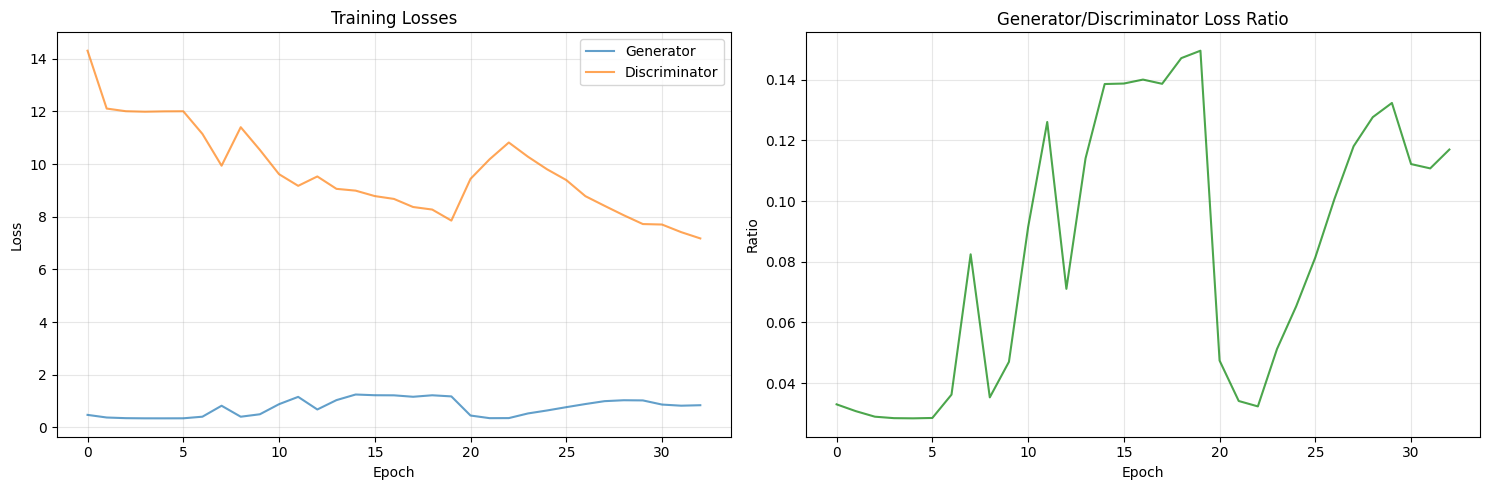

In [13]:
# trainer = GANTrainer(config, generator, discriminator, dataloader)
# logger.info('Starting GAN training...')
# history = trainer.train()

# Plot the training history
plot_training_history(history, config, save_path='training_history.png')

In [14]:
# import importlib
# import evaluation  # Replace with your module name
# import torch
# import torch.optim as optim
# from config import Config
# from model import TransformerGenerator, Discriminator, init_weights  # Import model classes directly
# from data_loader import create_dataloader  # Import dataloader function
# from trainer import GANTrainer 

# import evaluation
# # Make changes to `my_module.py` and save the file, then reload
# importlib.reload(evaluation)

# generator = TransformerGenerator(config, num_stocks=num_stocks).to(config.DEVICE)
# discriminator = Discriminator(config, num_stocks=num_stocks).to(config.DEVICE)

# # Generate Synthetic Data for Evaluation
# first_key = list(aligned_data_dict.keys())[0]
# real_data = stock_data[first_key]
# normalization_params_for_stock = normalization_params[first_key]
# stock_id = stock_to_id[first_key]  # Get the stock ID for the first stock

# generator_checkpoint = 'checkpoints/model_checkpoint_epoch_10.pth'
# discriminator_checkpoint = 'checkpoints/model_checkpoint_epoch_10.pth'

# # Call the synthetic data generation function
# synthetic_data = generate_synthetic_data(
#     generator_checkpoint=generator_checkpoint,
#     discriminator_checkpoint=discriminator_checkpoint,
#     generator=generator,
#     discriminator=discriminator,
#     real_data=real_data,
#     config=config,
#     normalization_params=normalization_params_for_stock,
#     stock_id=stock_id,
#     future_days=0,
#     n_samples=len(real_data)
# )

# # synthetic_data = generate_synthetic_data(
# #     generator=generator,
# #     real_data=real_data,
# #     config=config,
# #     normalization_params=normalization_params_for_stock,
# #     stock_id=stock_id,  # Pass stock_id here
# #     future_days=0
# # )

# # Plot Real vs Synthetic Data
# plot_results(
#     real_data=real_data,
#     synthetic_data=synthetic_data,
#     stock_name=first_key,
#     config=config,
#     future_days=0,
#     save_path='real_vs_synthetic.png'
# )

# # Evaluate Synthetic Data Quality
# metrics = evaluate_quality(real_data, synthetic_data, config)
# logger.info('Quality Evaluation Metrics:')
# for metric, value in metrics.items():
#     logger.info(f'{metric}: {value}')

# # Analyze Distributions of Real vs Synthetic Data
# analyze_distributions(real_data, synthetic_data, config, save_path='distribution_analysis.png')

In [15]:
aligned_data_dict

{'PCAR':                 Open      High       Low     Close    Volume
 2020-01-02 -0.830630 -0.909291 -0.816149 -0.819690 -0.004969
 2020-01-03 -0.924222 -1.000827 -0.920895 -0.904542 -0.156683
 2020-01-06 -0.928476 -1.035014 -0.948172 -0.936090  0.075737
 2020-01-07 -0.977400 -1.080231 -0.963448 -0.992657  0.006286
 2020-01-08 -0.931667 -0.958919 -0.966721 -0.879522  0.116569
 ...              ...       ...       ...       ...       ...
 2020-05-19 -1.837809 -1.948166 -1.922531 -2.011967  0.021135
 2020-05-20 -1.946291 -1.997793 -1.908347 -1.959750  0.269121
 2020-05-21 -1.912258 -2.061758 -1.972722 -2.051129 -0.552791
 2020-05-22 -2.032438 -2.137854 -2.029460 -2.026109 -0.387906
 2020-05-26 -1.815475 -1.671353 -1.810147 -1.577917  0.717078
 
 [100 rows x 5 columns],
 'VRTX':                 Open      High       Low     Close    Volume
 2020-01-02 -0.245089 -0.291541 -0.263505 -0.263251 -0.304554
 2020-01-03 -0.311050 -0.303262 -0.302883 -0.286826 -0.809969
 2020-01-06 -0.285668 -0.23


Starting evaluation:
Real data shape: (756, 5)
Generated synthetic data shape: (756, 5)
Debug info:
Real data shape: (756, 5)
Synthetic data shape: (756, 5)
Real data date range: 2020-01-02 00:00:00 to 2022-12-30 00:00:00
Synthetic data date range: 2020-01-02 00:00:00 to 2022-12-30 00:00:00


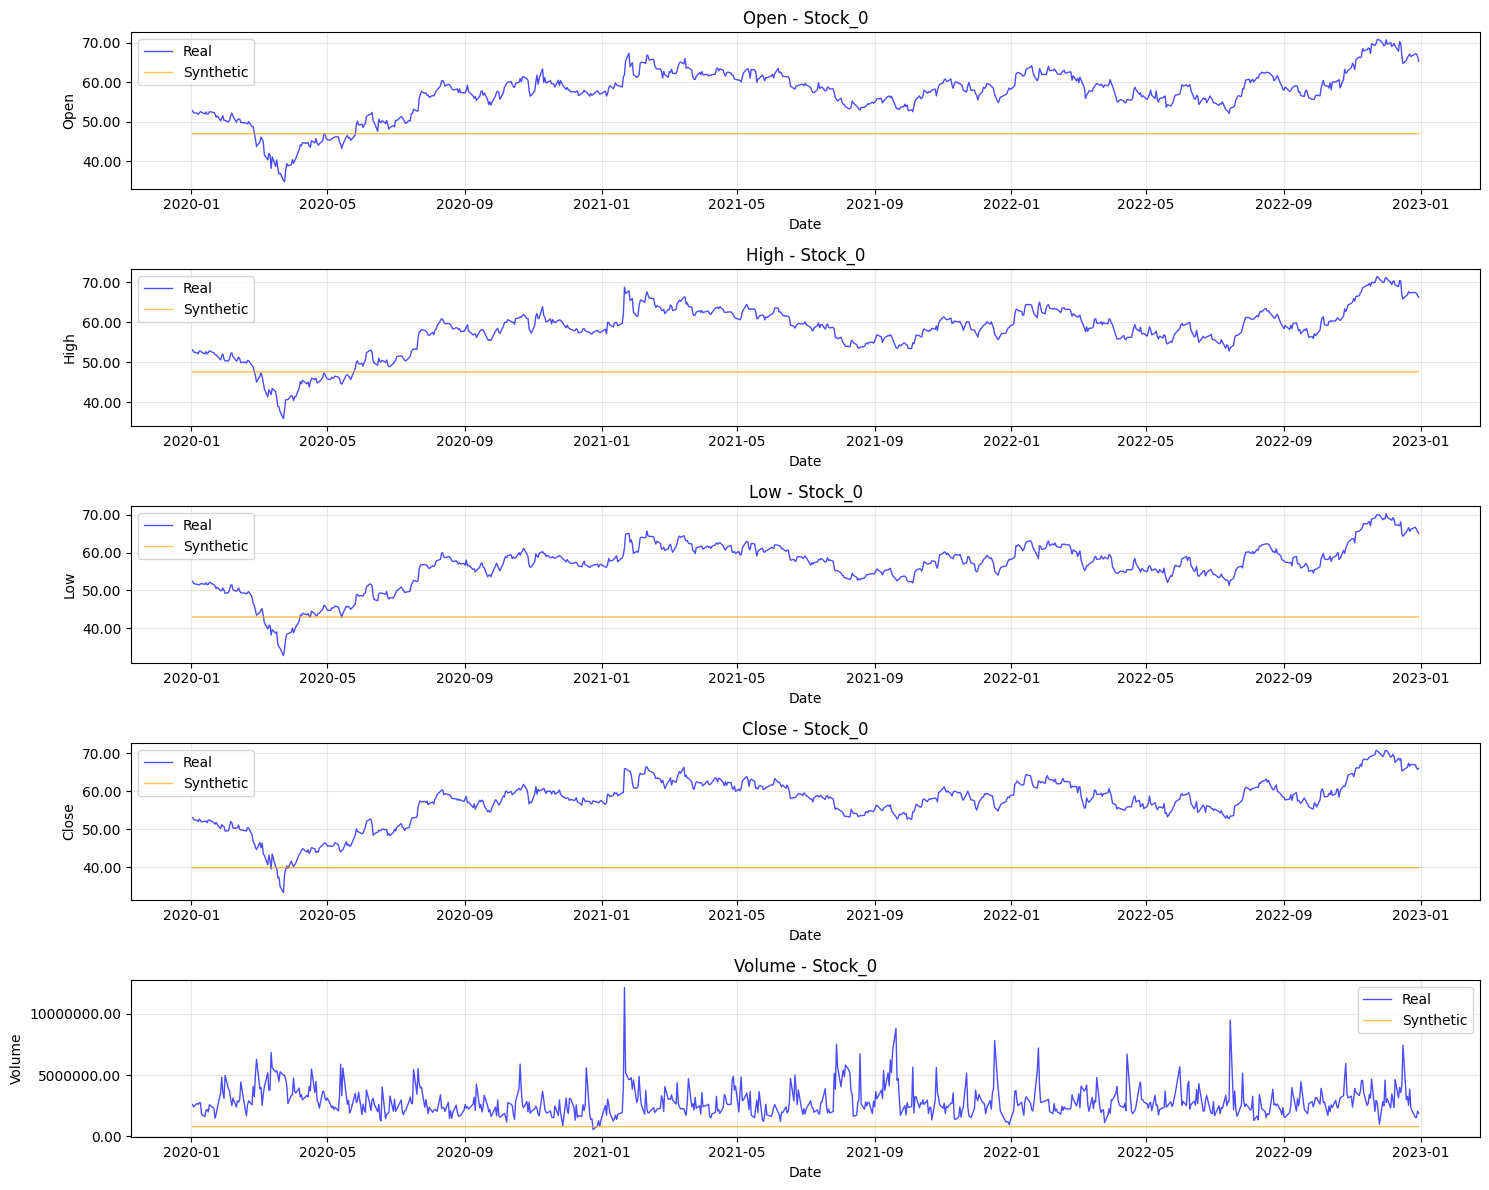


Evaluation Metrics:
ks_test_Open: 0.917989417989418
mae_Open: 10.88261264720291
correlation_Open: 0.04025165848353244
ks_test_High: 0.917989417989418
mae_High: 10.85325449484366
correlation_High: 0.15653996684163
ks_test_Low: 0.9682539682539683
mae_Low: 13.823417068158507
correlation_Low: -0.02152539633266705
ks_test_Close: 0.9880952380952381
mae_Close: 17.42465272530046
correlation_Close: 0.02047297938131179
ks_test_Volume: 0.9986772486772487
mae_Volume: 2068111.0989583333
correlation_Volume: -0.048303110260936796
volatility_diff: 0.0964280722825249
skew_diff_Open: 6.960477728118419
kurt_diff_Open: 54.423748626899
skew_diff_High: 3.2539760441206393
kurt_diff_High: 27.039732044194125
skew_diff_Low: 6.937748351895253
kurt_diff_Low: 63.05334593863942
skew_diff_Close: 4.908511022911293
kurt_diff_Close: 62.666469690399175
skew_diff_Volume: 5.395702677370471
kurt_diff_Volume: 29.828726549322866


In [17]:
import evaluation
import importlib

importlib.reload(evaluation)

from evaluation import evaluate_models

config = Config()

# Initialize models
generator = TransformerGenerator(
    config=config,
    num_stocks=num_stocks
).to(config.DEVICE)

# Get the first stock for evaluation
# Get the first stock for evaluation
first_key = list(aligned_data_dict.keys())[0]
real_data = stock_data[first_key]
norm_params_for_stock = {
    'median': normalization_params[first_key]['median'],
    'iqr': normalization_params[first_key]['iqr']
}
stock_id = stock_to_id[first_key]

# Run evaluation
synthetic_data, metrics = evaluate_models(
    real_data=real_data,
    config=config,
    generator=generator,
    stock_id=stock_id,
    normalization_params=norm_params_for_stock,
    checkpoint_path='checkpoints/model_checkpoint_epoch_30.pth',
    save_dir='evaluation_results'
)


# Print metrics
print("\nEvaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value}")

In [17]:
real_data

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,54.250000,54.419998,53.090000,53.540001,1771400
2020-01-03,53.119999,53.470001,52.689999,53.380001,1955300
2020-01-06,53.709999,54.980000,53.549999,54.630001,2429900
2020-01-07,54.389999,54.799999,54.130001,54.490002,2385800
2020-01-08,54.619999,55.470001,54.080002,55.020000,1979000
...,...,...,...,...,...
2022-12-23,51.470001,51.930000,51.279999,51.930000,536200
2022-12-27,52.000000,52.540001,51.980000,52.330002,640000
2022-12-28,52.250000,52.480000,51.320000,51.380001,921200


In [18]:
synthetic_data


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,37.769272,38.198303,37.657558,38.267807,2107428.25
2020-01-03,37.769115,38.198193,37.657261,38.268059,2107320.50
2020-01-06,37.769073,38.198166,37.657116,38.268524,2107262.50
2020-01-07,37.769108,38.198200,37.657104,38.268990,2107230.75
2020-01-08,37.769157,38.198223,37.657120,38.269318,2107197.25
...,...,...,...,...,...
2022-12-23,37.769650,38.198689,37.657913,38.269142,2107328.75
2022-12-27,37.769760,38.198818,37.657967,38.269672,2107328.25
2022-12-28,37.769905,38.198952,37.658054,38.270180,2107339.50


In [19]:
pd.DataFrame(synthetic_data)

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,37.769272,38.198303,37.657558,38.267807,2107428.25
2020-01-03,37.769115,38.198193,37.657261,38.268059,2107320.50
2020-01-06,37.769073,38.198166,37.657116,38.268524,2107262.50
2020-01-07,37.769108,38.198200,37.657104,38.268990,2107230.75
2020-01-08,37.769157,38.198223,37.657120,38.269318,2107197.25
...,...,...,...,...,...
2022-12-23,37.769650,38.198689,37.657913,38.269142,2107328.75
2022-12-27,37.769760,38.198818,37.657967,38.269672,2107328.25
2022-12-28,37.769905,38.198952,37.658054,38.270180,2107339.50


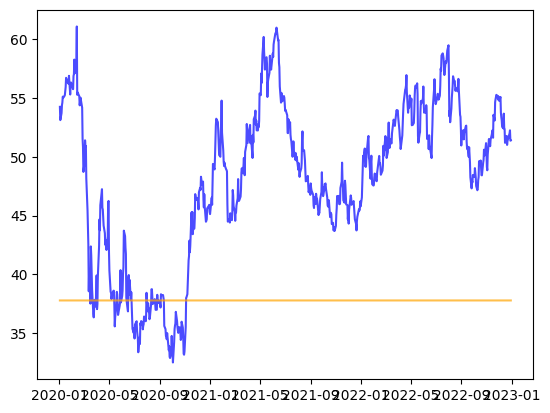

In [20]:
# plt.subplot(len(real_data.columns), 1, i)
import matplotlib.pyplot as plt

column = 'Open'
plt.plot(real_data.index, real_data[column], label='Real', color='blue', alpha=0.7)
historical_mask = synthetic_data.index <= real_data.index[-1]
plt.plot(synthetic_data[historical_mask].index, synthetic_data[historical_mask][column], label='Synthetic (Historical)', color='orange', alpha=0.7)

# if future_days > 0:
#     future_mask = synthetic_data.index > real_data.index[-1]
#     plt.plot(synthetic_data[future_mask].index, synthetic_data[future_mask][column], label='Synthetic (Future)', color='red', alpha=0.7, linestyle='--')
#     plt.axvline(x=real_data.index[-1], color='gray', linestyle=':', alpha=0.5, label='Present')

# plt.title(f'{column} - {stock_name}')
# plt.xlabel('Date')
# plt.ylabel(column)
# plt.legend()
# plt.grid(True, alpha=0.3)

In [21]:
normalization_params_for_stock

NameError: name 'normalization_params_for_stock' is not defined

In [26]:
synthetic_data

,Open,High,Low,Close,Volume
2020-01-02,121.082364,124.186265,111.146959,115.567069,8.616701e+06
2020-01-03,120.387995,124.012585,109.841272,114.970666,8.668364e+06
2020-01-06,119.933277,123.731187,109.290490,114.521220,8.681950e+06
2020-01-07,119.806664,123.232006,109.338667,114.201570,8.692120e+06
2020-01-08,119.798562,122.871982,109.824568,114.111452,8.694087e+06
...,...,...,...,...,...
2022-11-18,120.384419,124.002183,109.860473,114.973594,8.671067e+06
2022-11-21,119.971380,123.666495,109.275975,114.511984,8.682969e+06
2022-11-22,119.784902,123.242356,109.349824,114.200113,8.688170e+06
2022-11-23,119.777848,122.879272,109.808360,114.106022,8.691724e+06


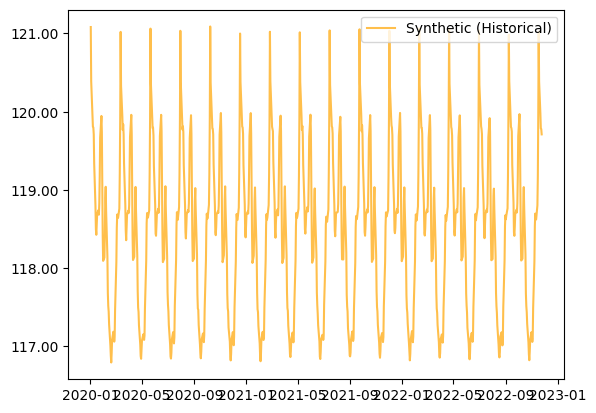

In [27]:
import matplotlib.pyplot as plt

# plt.plot(synthetic_data.index, synthetic_data['Open'], label='Synthetic (Historical)', color='orange', alpha=0.7)
import matplotlib.ticker as mticker

fig, ax = plt.subplots()
ax.plot(synthetic_data.index, synthetic_data['Open'], label='Synthetic (Historical)', color='orange', alpha=0.7)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.legend()
plt.show()


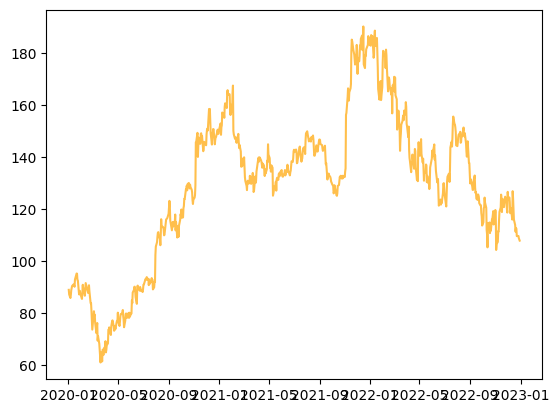

In [28]:
plt.plot(real_data.index, real_data['Open'], label='Synthetic (Historical)', color='orange', alpha=0.7)

In [29]:
from evaluation import load_model

n_samples = None
future_days = 0

generator = load_model(generator, generator_checkpoint, config.DEVICE)
discriminator = load_model(discriminator, discriminator_checkpoint, config.DEVICE)

median, iqr = normalization_params_for_stock
n_samples = n_samples or (len(real_data) + future_days)  # Adjust n_samples to include future_days if specified

synthetic_data_list = []
generated_rows = 0  # Track generated rows explicitly
print('n_samples', n_samples)
print('normalization_params', normalization_params_for_stock)

n_samples 756
normalization_params (array([1.32775002e+02, 1.34435005e+02, 1.31415001e+02, 1.32959999e+02,
       8.37840000e+06]), array([3.29024982e+01, 3.23950043e+01, 3.25824947e+01, 3.30324974e+01,
       4.09320000e+06]))


In [30]:
batch_size = min(config.BATCH_SIZE, n_samples - generated_rows)
batch_size

16

In [31]:
noise = torch.randn(batch_size, config.SEQUENCE_LENGTH, config.NOISE_DIM).to(config.DEVICE)
noise.shape

torch.Size([16, 50, 50])

In [32]:

stock_ids = torch.full((batch_size,), stock_id, dtype=torch.int64).to(config.DEVICE)
stock_ids


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [33]:
len(stock_ids)

16

In [34]:
synthetic_batch = generator(noise, stock_ids).cpu().detach().numpy()
synthetic_batch.shape

(16, 50, 5)

In [35]:
synthetic_data_list.append(synthetic_batch[:batch_size])
len(synthetic_data_list)


1

In [36]:
generated_rows += batch_size
generated_rows

16

In [37]:
synthetic_data = np.vstack(synthetic_data_list)[:n_samples]  # Stack and trim to n_samples
synthetic_data.shape


(16, 50, 5)

In [38]:
# Generate aligned dates with future dates if future_days > 0
dates = pd.date_range(start=real_data.index[0], periods=n_samples, freq='B')
dates


DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2022-11-11', '2022-11-14', '2022-11-15', '2022-11-16',
               '2022-11-17', '2022-11-18', '2022-11-21', '2022-11-22',
               '2022-11-23', '2022-11-24'],
              dtype='datetime64[ns]', length=756, freq='B')

In [39]:
# Apply stock-specific denormalization
synthetic_data = synthetic_data * iqr + median
synthetic_data.shape


(16, 50, 5)

In [40]:
# Create DataFrame with synthetic data
synthetic_df = pd.DataFrame(synthetic_data, index=dates, columns=real_data.columns)
synthetic_df

ValueError: Must pass 2-d input. shape=(16, 50, 5)

In [17]:
real_data

,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,89.050003,89.809998,88.080002,88.690002,8413900
2020-01-03,87.260002,87.639999,86.440002,87.019997,8340300
2020-01-06,85.910004,86.550003,85.540001,86.510002,8381400
2020-01-07,87.040001,89.489998,86.910004,88.970001,8377400
2020-01-08,88.900002,89.470001,87.919998,88.709999,7619900
...,...,...,...,...,...
2022-12-23,109.699997,110.919998,108.209999,110.839996,5356700
2022-12-27,109.750000,110.690002,108.889999,109.459999,6158100
2022-12-28,108.870003,110.269997,106.820000,106.970001,5395600


In [14]:
synthetic_data

,Open,High,Low,Close,Volume
2020-01-02,102.738143,104.182879,98.888521,99.257693,1.018938e+07
2020-01-03,102.734482,104.183464,98.891427,99.251326,1.018586e+07
2020-01-06,102.735382,104.181060,98.885600,99.242466,1.017826e+07
2020-01-07,102.736817,104.181010,98.881945,99.232984,1.017361e+07
2020-01-08,102.737396,104.180341,98.879533,99.229077,1.017038e+07
...,...,...,...,...,...
2022-11-18,102.735609,104.164746,98.874265,99.246927,1.015866e+07
2022-11-21,102.736857,104.164466,98.871447,99.241332,1.015533e+07
2022-11-22,102.737935,104.164867,98.868631,99.235866,1.015229e+07
2022-11-23,102.738261,104.164469,98.867077,99.233358,1.014998e+07


In [19]:
real_data.describe()

,Open,High,Low,Close,Volume
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02
mean,129.026587,130.981706,126.984445,128.979603,9.481904e+06
std,28.694464,29.104267,28.265776,28.673761,4.688076e+06
min,61.119999,64.860001,58.000000,60.910000,2.120200e+06
25%,113.730001,115.737499,111.682501,113.417500,6.658850e+06
50%,132.775002,134.435005,131.415001,132.959999,8.378400e+06
75%,146.632500,148.132504,144.264996,146.449997,1.075205e+07
max,190.300003,193.580002,185.190002,189.279999,4.832150e+07


In [20]:
synthetic_data.describe()

,Open,High,Low,Close,Volume
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02
mean,102.734166,104.168515,98.878521,99.244321,1.016228e+07
std,0.002579,0.006588,0.006122,0.013283,8.742750e+03
min,102.726792,104.158721,98.863810,99.212098,1.014452e+07
25%,102.732240,104.163500,98.873437,99.235723,1.015638e+07
50%,102.734007,104.165966,98.878981,99.245102,1.016176e+07
75%,102.736111,104.174095,98.883509,99.253937,1.016630e+07
max,102.741155,104.184705,98.891046,99.274661,1.019019e+07


In [17]:
synthetic_data.describe()

,Open,High,Low,Close,Volume
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02
mean,103.667120,107.384395,106.381872,93.071658,1.295483e+07
std,0.041407,0.018515,0.024743,0.029642,9.647064e+03
min,103.483387,107.319685,106.319817,92.967963,1.293001e+07
25%,103.639142,107.372182,106.363745,93.052194,1.294766e+07
50%,103.667612,107.384358,106.380278,93.073938,1.295506e+07
75%,103.697226,107.397617,106.401503,93.092303,1.296074e+07
max,103.766325,107.430872,106.446889,93.153298,1.298033e+07


,Open,High,Low,Close,Volume
2020-01-02,127.947409,123.078456,128.334924,126.348186,8.294135e+06
2020-01-03,127.835558,123.076659,128.140539,126.426148,8.278816e+06
2020-01-06,127.932183,122.938392,128.422544,126.440371,8.300227e+06
2020-01-07,127.885619,122.965052,128.342967,126.338727,8.303669e+06
2020-01-08,127.688792,122.900480,128.118702,126.335869,8.309994e+06
...,...,...,...,...,...
2106-12-02,127.668096,122.855147,128.315421,126.427897,8.299277e+06
2106-12-03,127.728955,122.964486,128.157292,126.335620,8.286868e+06
2106-12-06,127.500401,122.973038,128.109345,126.313657,8.280567e+06
2106-12-07,127.582685,122.961442,128.082018,126.340849,8.288771e+06
